# 03 — Détection d'anomalies : Autoencodeur convolutionnel et VAE

Ce notebook implémente en Keras/TensorFlow :
1. **AE convolutionnel** — score d'anomalie via erreur de reconstruction MSE
2. **VAE convolutionnel** — score hybride reconstruction + KL divergence
3. Analyse des cas à forte atypicité, t-SNE de l'espace latent
4. Tracking MLflow des deux modèles

In [1]:
import json
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
import keras
from keras import layers, Model, ops

from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE

import mlflow

DATA_DIR   = Path('../Projet_Deep_Learning/data/variable_data')
MODELS_DIR = Path('../Projet_Deep_Learning/models')

with open(DATA_DIR / 'config.json') as f:
    cfg = json.load(f)

SEED     = cfg['seed']
IMG_SIZE = cfg['img_size']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')

2026-03-28 12:53:53.305588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 12:53:57.538148: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-28 12:54:11.731217: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0 | Keras 3.12.0


## 1. Données — images normales uniquement pour l'entraînement AE

In [2]:
X_train_norm = np.load(DATA_DIR / 'X_train_norm.npy')
X_test_norm  = np.load(DATA_DIR / 'X_test_norm.npy')
y_train      = np.load(DATA_DIR / 'y_train.npy')
y_test       = np.load(DATA_DIR / 'y_test.npy')

# l'autoencodeur est entraine exclusivement sur des images normales, c'est ce qui lui permet de detecter les anomalies par la suite
normal_mask   = y_train.sum(axis=1) == 0
X_train_normal = X_train_norm[normal_mask]

# on cree des labels binaires simples pour l'evaluation : 0 pour normal, 1 des qu'il y a au moins une pathologie
anomaly_labels = (y_test.sum(axis=1) > 0).astype(int)

print(f'Images normales (train AE): {len(X_train_normal)}')
print(f'Images test: {len(X_test_norm)} | Taux anomalies: {anomaly_labels.mean():.2%}')

BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

def make_ae_dataset(X, shuffle=False):
    def gen():
        for img in X:
            yield img.astype(np.float32)
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=tf.TensorSpec(shape=X.shape[1:], dtype=tf.float32)
    )
    if shuffle:
        ds = ds.shuffle(min(len(X), 2000), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ae_ds = make_ae_dataset(X_train_normal, shuffle=True)
test_ae_ds  = make_ae_dataset(X_test_norm)

Images normales (train AE): 42405
Images test: 22433 | Taux anomalies: 46.83%


I0000 00:00:1774698881.275596   63195 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 2. Architecture AE convolutionnel Keras

In [3]:
def build_encoder(img_size: int, latent_dim: int) -> Model:
    """Encodeur convolutif avec stride=2 à chaque bloc.
    
    L'utilisation de Conv2D stride=2 à la place de MaxPool permet la reconstruction
    symétrique via Conv2DTranspose sans ambiguïté de taille.
    """
    inp = layers.Input(shape=(img_size, img_size, 1), name='enc_input')

    x = layers.Conv2D(32,  4, strides=2, padding='same', use_bias=False)(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64,  4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x   = layers.Flatten()(x)
    out = layers.Dense(latent_dim, name='latent')(x)

    return Model(inp, out, name='encoder')


def build_decoder(latent_dim: int, spatial_dim: int = 4) -> Model:
    """Décodeur symétrique via Conv2DTranspose."""
    inp = layers.Input(shape=(latent_dim,), name='dec_input')

    x = layers.Dense(256 * spatial_dim * spatial_dim, activation='relu')(inp)
    x = layers.Reshape((spatial_dim, spatial_dim, 256))(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # on utilise tanh en sortie parce que les images sont normalisees entre -1 et 1
    out = layers.Conv2DTranspose(1, 4, strides=2, padding='same', activation='tanh',
                                  name='reconstruction')(x)

    return Model(inp, out, name='decoder')


def build_conv_ae(img_size: int, latent_dim: int = 128) -> Model:
    encoder = build_encoder(img_size, latent_dim)
    decoder = build_decoder(latent_dim)

    inp   = layers.Input(shape=(img_size, img_size, 1))
    z     = encoder(inp)
    recon = decoder(z)

    return Model(inp, recon, name='ConvAE')


ae_model = build_conv_ae(IMG_SIZE, latent_dim=128)
ae_model.summary(line_length=80)
print(f'ConvAE — paramètres: {ae_model.count_params():,}')

Model: "ConvAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 64, 64, 1)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ encoder (Functional)              │ (None, 128)              │     1,214,848 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ decoder (Functional)              │ (None, 64, 64, 1)        │     1,217,921 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,432,769 (9.28 MB)

 Trainable params: 2,431,425 (9.28 MB)

 Non-trainable params: 1,344 (5.25 KB)

ConvAE — paramètres: 2,432,769


## 3. Architecture VAE convolutionnel Keras

In [4]:
class SamplingLayer(layers.Layer):
    """Reparameterization trick : z = mu + eps * exp(0.5 * logvar).
    
    Implémenté comme une couche Keras pour intégration native dans le
    graphe computationnel et compatibilité avec model.save().
    """
    def get_config(self):
        return super().get_config()

    def call(self, inputs, training=None):
        mu, logvar = inputs
        if not training:
            return mu  # en inférence, utiliser la moyenne directement
        std = tf.exp(0.5 * logvar)
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * std


class ConvVAE(Model):
    """VAE convolutionnel avec perte ELBO (reconstruction + KL divergence).
    
    Le score d'anomalie combine les deux termes : une image atypique peut
    être mal reconstruite (forte erreur MSE) et/ou mal encodée (forte KL).
    L'override de train_step/test_step permet l'intégration native avec model.fit().
    """

    def __init__(self, img_size: int, latent_dim: int = 128, beta: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.img_size   = img_size
        self.latent_dim = latent_dim
        self.beta       = beta  # beta-VAE : pondère la régularisation KL

        # meme architecture d'encodeur que l'AE pour faciliter la comparaison
        enc_inp = layers.Input(shape=(img_size, img_size, 1))
        h = layers.Conv2D(32,  4, strides=2, padding='same', use_bias=False)(enc_inp)
        h = layers.LeakyReLU(0.2)(h)
        h = layers.Conv2D(64,  4, strides=2, padding='same', use_bias=False)(h)
        h = layers.BatchNormalization()(h)
        h = layers.LeakyReLU(0.2)(h)
        h = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(h)
        h = layers.BatchNormalization()(h)
        h = layers.LeakyReLU(0.2)(h)
        h = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(h)
        h = layers.BatchNormalization()(h)
        h = layers.LeakyReLU(0.2)(h)
        h = layers.Flatten()(h)

        mu     = layers.Dense(latent_dim, name='mu')(h)
        logvar = layers.Dense(latent_dim, name='logvar')(h)

        self.encoder = Model(enc_inp, [mu, logvar], name='vae_encoder')
        self.sampling = SamplingLayer()
        self.decoder  = build_decoder(latent_dim)

        # trackers pour suivre les differentes composantes de la perte pendant l'entrainement
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    def get_config(self):
        config = super().get_config()
        config.update({'img_size': self.img_size, 'latent_dim': self.latent_dim, 'beta': self.beta})
        return config

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x, training=None):
        mu, logvar = self.encoder(x, training=training)
        z          = self.sampling([mu, logvar], training=training)
        recon      = self.decoder(z, training=training)
        return recon, mu, logvar

    def _compute_losses(self, x, training):
        recon, mu, logvar = self(x, training=training)
        # erreur de reconstruction MSE calculee sur tous les pixels
        recon_loss = tf.reduce_mean(tf.square(x - recon))
        # divergence KL analytique par rapport a une gaussienne standard
        kl_loss    = -0.5 * tf.reduce_mean(1.0 + logvar - tf.square(mu) - tf.exp(logvar))
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data, training=True)
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        total_loss, recon_loss, kl_loss = self._compute_losses(data, training=False)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


vae_model = ConvVAE(IMG_SIZE, latent_dim=128, beta=1.0, name='ConvVAE')
# on force le build du modele avec un batch vide avant de l'afficher
_ = vae_model(np.zeros((1, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32))
print(f'ConvVAE — encoder params: {vae_model.encoder.count_params():,}')

2026-03-28 12:54:43.565799: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


ConvVAE — encoder params: 1,739,264


## 4. Fonctions de scoring d'anomalie

In [5]:
def anomaly_scores_ae(model: Model, dataset) -> np.ndarray:
    """Score AE = erreur de reconstruction MSE par image."""
    scores = []
    for batch in dataset:
        recon = model(batch, training=False)
        mse   = tf.reduce_mean(tf.square(batch - recon), axis=[1, 2, 3])
        scores.extend(mse.numpy())
    return np.array(scores)


def anomaly_scores_vae(model: ConvVAE, dataset) -> np.ndarray:
    """Score VAE = reconstruction MSE + KL par image.
    
    Capture deux formes d'atypicité : images mal reconstruites (forte MSE)
    et images dont la représentation latente dévie de N(0,1) (forte KL).
    """
    scores = []
    for batch in dataset:
        recon, mu, logvar = model(batch, training=False)
        mse_per_img = tf.reduce_mean(tf.square(batch - recon), axis=[1, 2, 3])
        kl_per_img  = -0.5 * tf.reduce_mean(
            1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1
        )
        combined = mse_per_img + kl_per_img
        scores.extend(combined.numpy())
    return np.array(scores)

print('Fonctions de scoring définies')

Fonctions de scoring définies


## 5. Entraînement — ConvAE

In [6]:
mlflow.set_experiment('chest_anomaly_detection')

ae_model = build_conv_ae(IMG_SIZE, latent_dim=128)
ae_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

train_ae_ds_paired = (tf.data.Dataset
                       .from_tensor_slices((X_train_normal.astype(np.float32),
                                            X_train_normal.astype(np.float32)))
                       .shuffle(len(X_train_normal), seed=SEED)
                       .batch(BATCH_SIZE)
                       .prefetch(AUTOTUNE))

test_ae_ds_paired = (tf.data.Dataset
                      .from_tensor_slices((X_test_norm.astype(np.float32),
                                           X_test_norm.astype(np.float32)))
                      .batch(BATCH_SIZE)
                      .prefetch(AUTOTUNE))

with mlflow.start_run(run_name='ConvAE'):
    mlflow.log_params({
        'model': 'ConvAE', 'latent_dim': 128,
        'n_epochs': 40, 'lr': 1e-3, 'training_data': 'normal_only'
    })

    ae_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, verbose=1),
        keras.callbacks.ModelCheckpoint(
            str(MODELS_DIR / 'ConvAE_best.keras'),
            monitor='val_loss', save_best_only=True, verbose=0
        )
    ]

    ae_hist = ae_model.fit(
        train_ae_ds_paired,
        validation_data=test_ae_ds_paired,
        epochs=40,
        callbacks=ae_callbacks,
        verbose=2
    )

    for ep, loss_val in enumerate(ae_hist.history['loss']):
        mlflow.log_metrics({'train_loss': loss_val,
                             'val_loss': ae_hist.history['val_loss'][ep]}, step=ep + 1)

    ae_scores = anomaly_scores_ae(ae_model, test_ae_ds)
    ae_auc    = roc_auc_score(anomaly_labels, ae_scores)
    mlflow.log_metric('anomaly_roc_auc', ae_auc)
    mlflow.log_artifact(str(MODELS_DIR / 'ConvAE_best.keras'))

print(f'ConvAE — AUC détection anomalie: {ae_auc:.4f}')

Epoch 1/40


2026-03-28 12:54:58.521500: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5e4c0199d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-28 12:54:58.521543: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6


2026-03-28 12:54:58.794596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-03-28 12:55:00.936923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2472', 8 bytes spill stores, 8 bytes spill loads



I0000 00:00:1774698906.431916   63476 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...


Epoch 40: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


663/663 - 5s - 7ms/step - loss: 0.0030 - val_loss: 0.0034 - learning_rate: 3.1250e-05


Restoring model weights from the end of the best epoch: 39.


2026-03-28 13:00:00.595559: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ConvAE — AUC détection anomalie: 0.5399


## 6. Entraînement — ConvVAE

In [7]:
vae_model = ConvVAE(IMG_SIZE, latent_dim=128, beta=1.0, name='ConvVAE')
vae_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae_model(np.zeros((1, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32))

with mlflow.start_run(run_name='ConvVAE'):
    mlflow.log_params({
        'model': 'ConvVAE', 'latent_dim': 128, 'beta': 1.0,
        'n_epochs': 40, 'lr': 1e-3, 'training_data': 'normal_only'
    })

    vae_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, verbose=1),
        keras.callbacks.ModelCheckpoint(
            str(MODELS_DIR / 'ConvVAE_best.keras'),
            monitor='val_loss', save_best_only=True, verbose=0
        )
    ]

    vae_hist = vae_model.fit(
        train_ae_ds,
        validation_data=test_ae_ds,
        epochs=40,
        callbacks=vae_callbacks,
        verbose=2
    )

    for ep, loss_val in enumerate(vae_hist.history['loss']):
        mlflow.log_metrics({
            'train_loss':  loss_val,
            'val_loss':    vae_hist.history['val_loss'][ep],
            'recon_loss':  vae_hist.history.get('recon_loss', [0])[ep],
            'kl_loss':     vae_hist.history.get('kl_loss',    [0])[ep],
        }, step=ep + 1)

    vae_scores = anomaly_scores_vae(vae_model, test_ae_ds)
    vae_auc    = roc_auc_score(anomaly_labels, vae_scores)
    mlflow.log_metric('anomaly_roc_auc', vae_auc)
    mlflow.log_artifact(str(MODELS_DIR / 'ConvVAE_best.keras'))

print(f'ConvVAE — AUC détection anomalie: {vae_auc:.4f}')

Epoch 1/40


2026-03-28 13:00:16.060247: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 13:00:16.060327: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-03-28 13:00:16.560588: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 8 bytes spill stores, 8 bytes spill loads



2026-03-28 13:00:16.987739: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2402', 8 bytes spill stores, 8 bytes spill loads

2026-03-28 13:00:17.166831: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 96 bytes spill stores, 96 bytes spill loads



2026-03-28 13:00:18.178870: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 152 bytes spill stores, 152 bytes spill loads



...

663/663 - 14s - 21ms/step - kl_loss: 0.0282 - loss: 0.0867 - recon_loss: 0.0585 - val_kl_loss: 0.0279 - val_loss: 0.0721 - val_recon_loss: 0.0442 - learning_rate: 1.2500e-04


Epoch 28: early stopping


Restoring model weights from the end of the best epoch: 22.


2026-03-28 13:06:13.910064: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11706852825670929679


ConvVAE — AUC détection anomalie: 0.5246


## 7. Évaluation et visualisations

AE  — ROC-AUC: 0.5399
VAE — ROC-AUC: 0.5246


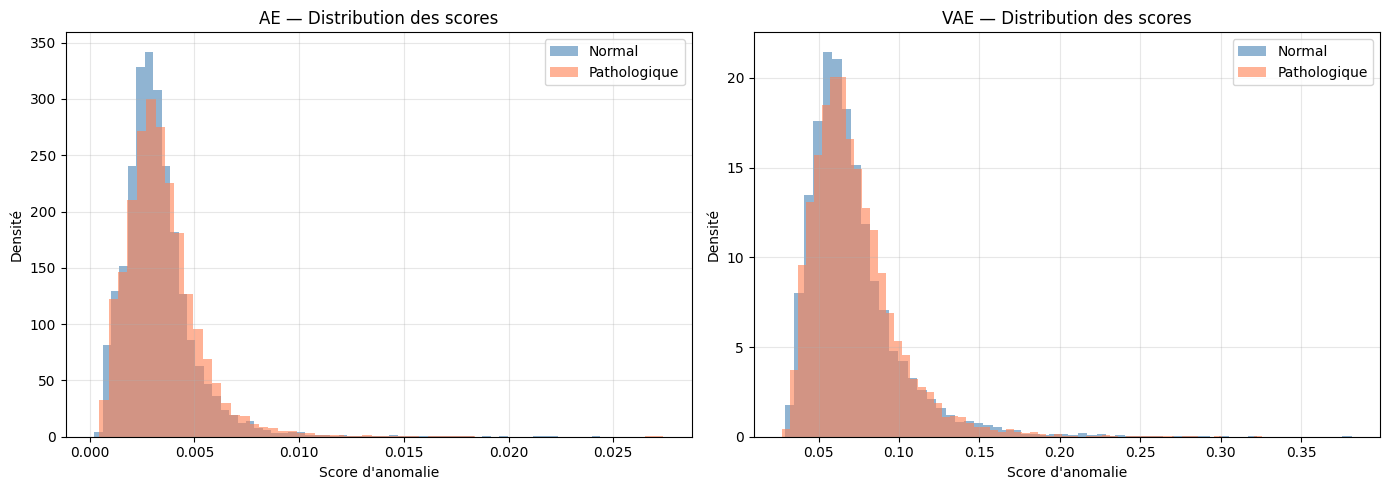

In [8]:
print(f'AE  — ROC-AUC: {ae_auc:.4f}')
print(f'VAE — ROC-AUC: {vae_auc:.4f}')

# on visualise la distribution des scores d'anomalie pour comparer les images normales et pathologiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, title in zip(axes, [ae_scores, vae_scores], ['AE', 'VAE']):
    ax.hist(scores[anomaly_labels == 0], bins=60, alpha=0.6, label='Normal',
            color='steelblue', density=True)
    ax.hist(scores[anomaly_labels == 1], bins=60, alpha=0.6, label='Pathologique',
            color='coral', density=True)
    ax.set_xlabel('Score d\'anomalie')
    ax.set_ylabel('Densité')
    ax.set_title(f'{title} — Distribution des scores')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'anomaly_score_distribution.png', dpi=120)
plt.show()

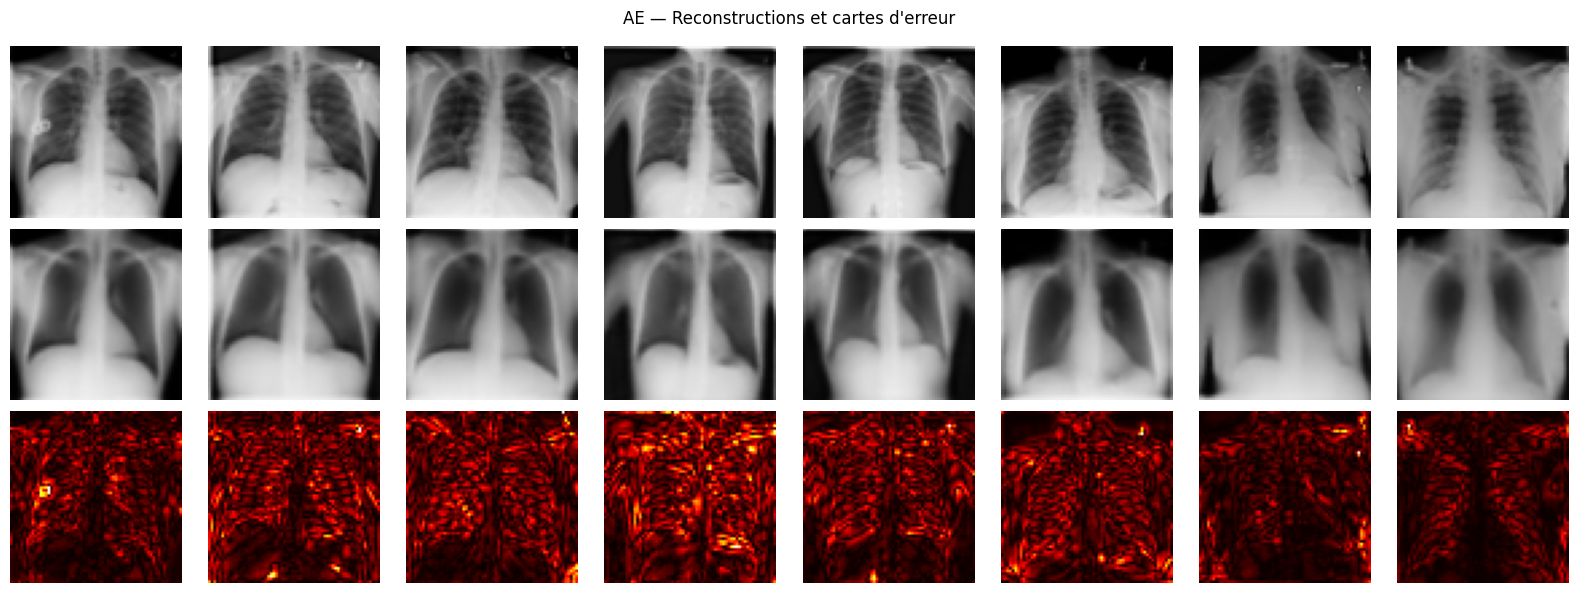

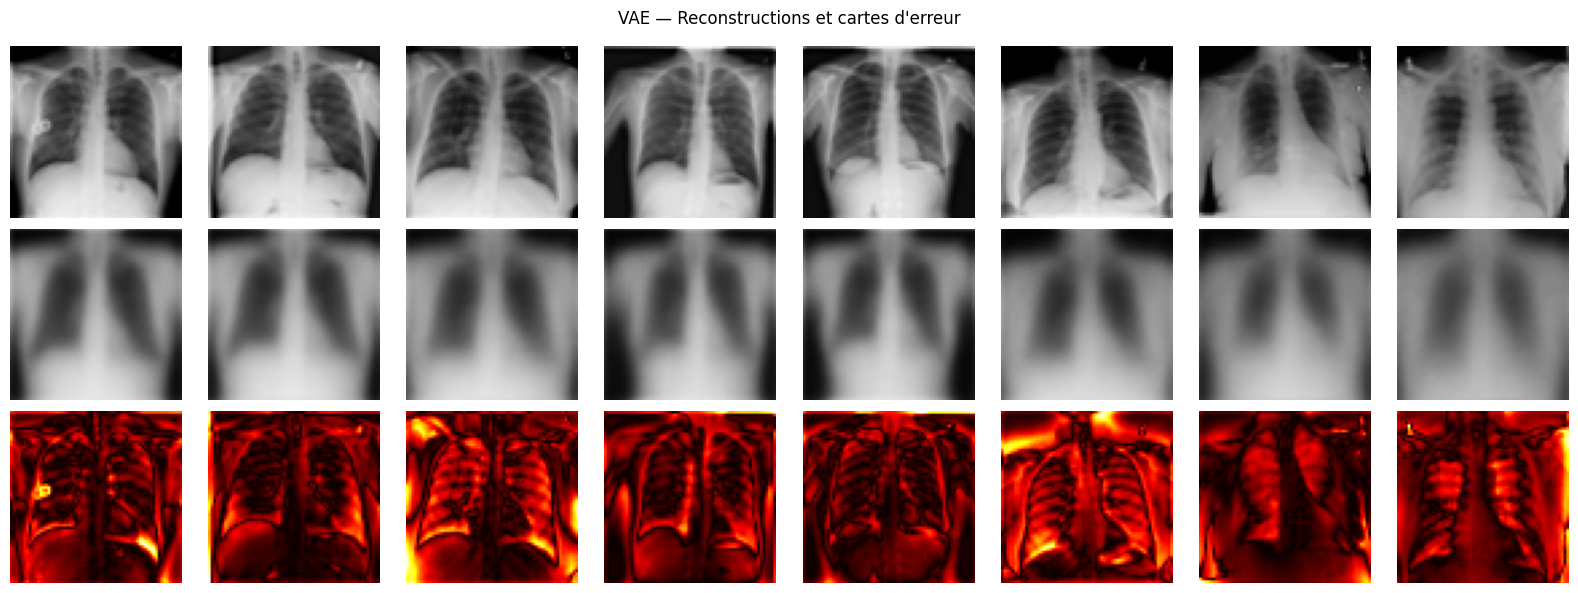

In [9]:
# on regarde quelques exemples de reconstructions pour avoir une idee visuelle de ce que fait le modele
n_show  = 8
samples = X_test_norm[:n_show]

ae_recons  = ae_model.predict(samples, verbose=0)
vae_out    = vae_model(samples, training=False)
vae_recons = vae_out[0].numpy()

for model_name, recons in [('AE', ae_recons), ('VAE', vae_recons)]:
    fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2, 6))
    for col in range(n_show):
        orig  = samples[col].squeeze()
        rec   = recons[col].squeeze()
        err   = np.abs(orig - rec)
        axes[0, col].imshow(orig, cmap='gray', vmin=-1, vmax=1)
        axes[1, col].imshow(rec,  cmap='gray', vmin=-1, vmax=1)
        axes[2, col].imshow(err,  cmap='hot')
        for row in range(3):
            axes[row, col].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=8)
    axes[1, 0].set_ylabel('Reconstruction', fontsize=8)
    axes[2, 0].set_ylabel('Erreur', fontsize=8)
    plt.suptitle(f'{model_name} — Reconstructions et cartes d\'erreur')
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'reconstructions_{model_name}.png', dpi=100)
    plt.show()

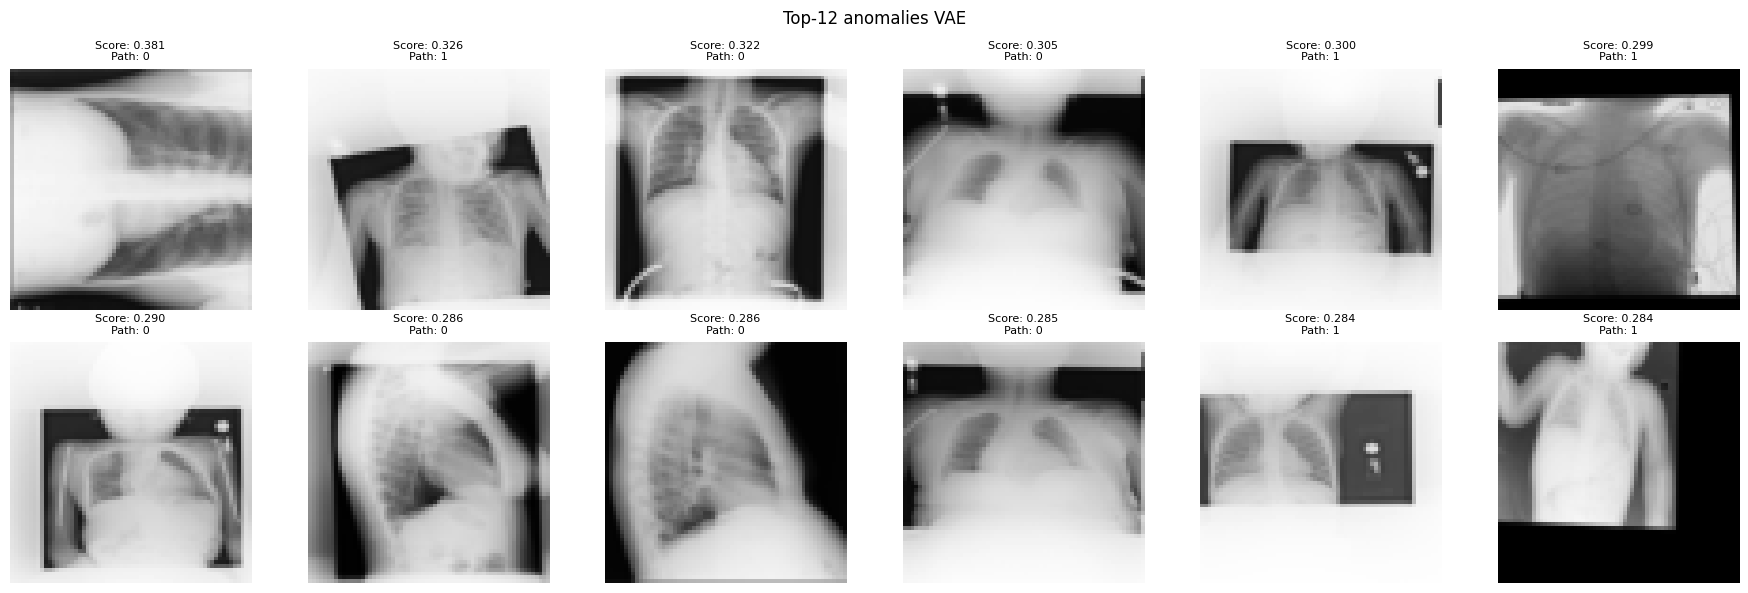

Precision@50: 0.380
Precision@100: 0.290
Precision@200: 0.360


In [10]:
# on affiche les K images avec les scores d'anomalie les plus eleves selon le VAE
n_top = 12
top_indices = np.argsort(vae_scores)[::-1][:n_top]

fig, axes = plt.subplots(2, n_top // 2, figsize=(n_top * 1.5, 6))
for plot_idx, data_idx in enumerate(top_indices):
    ax  = axes.flatten()[plot_idx]
    img = X_test_norm[data_idx].squeeze()
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'Score: {vae_scores[data_idx]:.3f}\nPath: {anomaly_labels[data_idx]}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'Top-{n_top} anomalies VAE')
plt.tight_layout()
plt.savefig(DATA_DIR / 'top_anomalies_vae.png', dpi=100)
plt.show()

for k in [50, 100, 200]:
    top_k = np.argsort(vae_scores)[::-1][:k]
    print(f'Precision@{k}: {anomaly_labels[top_k].mean():.3f}')

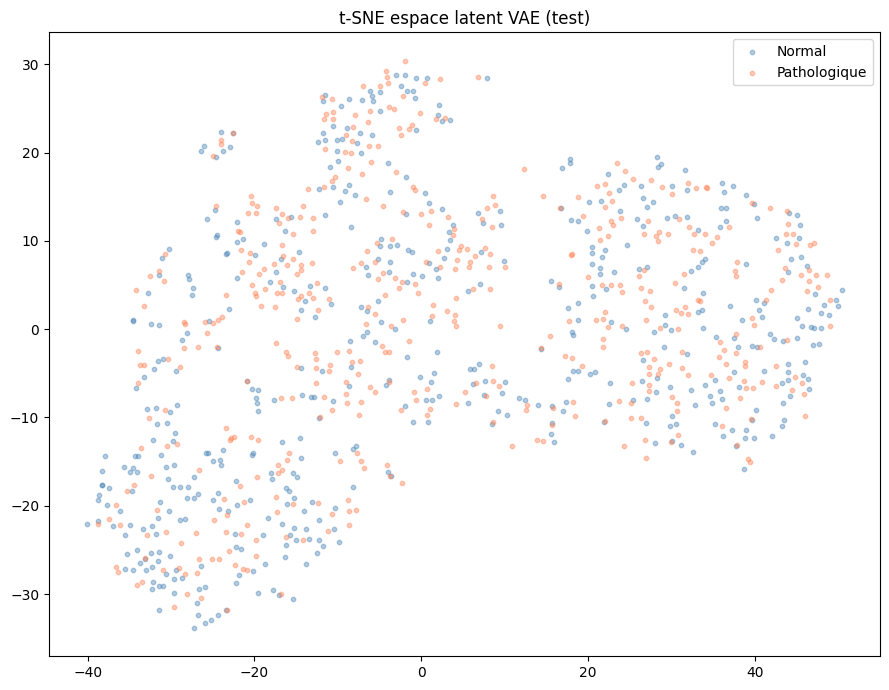

In [11]:
# on projette l'espace latent du VAE en 2D avec t-SNE pour voir si les normaux et pathologiques se separent bien
n_tsne     = 1000
sample_idx = np.random.choice(len(X_test_norm), n_tsne, replace=False)
X_sample   = X_test_norm[sample_idx]

mu_vals, _ = vae_model.encoder.predict(X_sample, verbose=0)
labels_sample = anomaly_labels[sample_idx]

tsne   = TSNE(n_components=2, random_state=SEED, perplexity=30)
coords = tsne.fit_transform(mu_vals)

fig, ax = plt.subplots(figsize=(9, 7))
for cls_label, color, name in [(0, 'steelblue', 'Normal'), (1, 'coral', 'Pathologique')]:
    mask = labels_sample == cls_label
    ax.scatter(coords[mask, 0], coords[mask, 1], c=color, label=name, alpha=0.4, s=10)
ax.legend()
ax.set_title('t-SNE espace latent VAE (test)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'vae_latent_tsne.png', dpi=120)
plt.show()